## Model Training
---

In [ ]:
# importing the required libraries library 
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# reading the dataset csv file that will required for model training
df = pd.read_csv('..\\datasets\\email_data_cleaned.csv')

df.head()

,Subject,Message,Spam/Ham
0,"vastar resources , inc .","gary , production from the high island larger ...",ham
1,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham
2,re : issue,fyi - see note below - already done .\nstella\...,ham
3,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham
4,mcmullen gas for 11 / 99,"jackie ,\nsince the inlet to 3 river plant is ...",ham


In [ ]:
from sklearn.model_selection import train_test_split

# Define X by dropping target columns and redundant features
X = df.drop(columns=['Spam/Ham'])
y = df['Spam/Ham']

# Split the data (80% for training and 20% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# display the shape of training and testing data
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (26485, 2)
Testing features shape: (6622, 2)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Create a separate vectorizer for the Subject column
tfidf_subject = TfidfVectorizer(stop_words='english')
X_train_subj_vec = tfidf_subject.fit_transform(X_train['Subject'])
X_test_subj_vec = tfidf_subject.transform(X_test['Subject'])

# Create a separate vectorizer for the Message column
tfidf_message = TfidfVectorizer(stop_words='english')
X_train_msg_vec = tfidf_message.fit_transform(X_train['Message'])
X_test_msg_vec = tfidf_message.transform(X_test['Message'])

# Horizontally stack the numerical matrices together
X_train_final = hstack([X_train_subj_vec, X_train_msg_vec])
X_test_final = hstack([X_test_subj_vec, X_test_msg_vec])


In [ ]:
from sklearn.linear_model import LogisticRegression

# initialize the model
model = LogisticRegression(max_iter=1000)

# train the model using the training data
model.fit(X_train_final, y_train)



,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Confusion Matrix: 
[[3238   69]
 [  16 3299]]


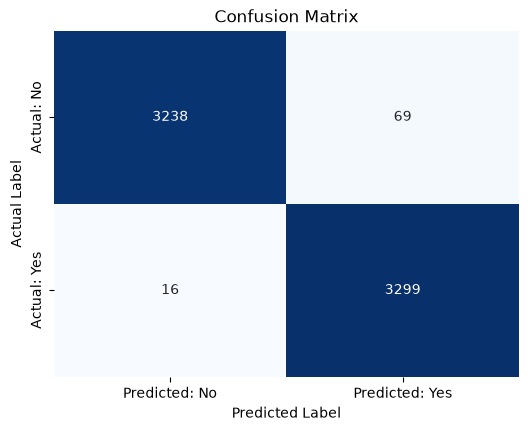

In [ ]:
from sklearn.metrics import  confusion_matrix
y_pred_log = model.predict(X_test_final)
y_pred_proba = model.predict_proba(X_test_final)[:, 1]


print("Confusion Matrix: ")
print(confusion_matrix(y_test, y_pred_log))

cm = confusion_matrix(y_test, y_pred_log)

# Plot simple heatmap
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: No', 'Predicted: Yes'],
            yticklabels=['Actual: No', 'Actual: Yes'])

plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

print("\nClassification Report: ")
print(classification_report(y_test, y_pred_log))

print("Performance Summary: ")
print(f"Overall Test Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"ROC-AUC Score:         {roc_auc_score(y_test, y_pred_proba):.4f}")


Classification Report: 
              precision    recall  f1-score   support

         ham       1.00      0.98      0.99      3307
        spam       0.98      1.00      0.99      3315

    accuracy                           0.99      6622
   macro avg       0.99      0.99      0.99      6622
weighted avg       0.99      0.99      0.99      6622

Performance Summary: 
Overall Test Accuracy: 0.9872
ROC-AUC Score:         0.9992


In [ ]:
from scipy.sparse import hstack

# Step 1: Simulate receiving brand-new incoming emails
new_emails = [
    {
        "Subject": "Urgent: Reset your account password immediately",
        "Message": "Dear user, we detected a suspicious login attempt on your account. Click this link to confirm your details and claim your $500 bonus reward."
    },
    {
        "Subject": "Project Review Meeting Agenda",
        "Message": "Hi Team, please find attached the slide deck for tomorrow's 10 AM synchronization call regarding the Q3 product roadmap."
    }
]

# Convert the new incoming entries into a Pandas DataFrame
new_df = pd.DataFrame(new_emails)

# Step 2: Handle missing text fields just in case
new_df['Subject'] = new_df['Subject'].fillna('')
new_df['Message'] = new_df['Message'].fillna('')

# Step 3: Use .transform() (NOT fit_transform!) to match the training vocabulary
new_subj_vec = tfidf_subject.transform(new_df['Subject'])
new_msg_vec = tfidf_message.transform(new_df['Message'])

# Step 4: Horizontally stack the new vectors together
new_features_final = hstack([new_subj_vec, new_msg_vec])

# Step 5: Make predictions using your trained model
predictions = model.predict(new_features_final)

# Optional: Get the exact confidence probabilities for each prediction
probabilities = model.predict_proba(new_features_final)

# Step 6: Print out the final results
for i, pred in enumerate(predictions):
    confidence = probabilities[i].max() * 100
    print(f"Email {i+1} Subject: '{new_df['Subject'].iloc[i]}'")
    print(f"--> Predicted Category: {pred.upper()} ({confidence:.2f}% confidence)\n")


Email 1 Subject: 'Urgent: Reset your account password immediately'
--> Predicted Category: SPAM (96.14% confidence)

Email 2 Subject: 'Project Review Meeting Agenda'
--> Predicted Category: HAM (95.48% confidence)



In [ ]:
import joblib
import os

# Create the models folder if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained Logistic Regression model
joblib.dump(model, "../models/spam_model.pkl")

# Save the Subject TF-IDF Vectorizer
joblib.dump(tfidf_subject, "../models/tfidf_subject.pkl")

# Save the Message TF-IDF Vectorizer
joblib.dump(tfidf_message, "../models/tfidf_message.pkl")

print(" Model and vectorizers saved successfully!")